In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/otto-group-product-classification-challenge/sampleSubmission.csv
/kaggle/input/competitions/otto-group-product-classification-challenge/train.csv
/kaggle/input/competitions/otto-group-product-classification-challenge/test.csv


In [2]:
SEED = 42
np.random.seed(SEED)

PATH = "/kaggle/input/competitions/otto-group-product-classification-challenge/"

train = pd.read_csv(PATH + "train.csv")
test = pd.read_csv(PATH + "test.csv")
sample_sub = pd.read_csv(PATH + "sampleSubmission.csv")

print("train:", train.shape)
print("test:", test.shape)
print("sample_sub:", sample_sub.shape)

train: (61878, 95)
test: (144368, 94)
sample_sub: (144368, 10)


In [3]:
FEATS = [f"feat_{i}" for i in range(1, 94)]

test_ids = test["id"].values
X = train[FEATS].copy()
X_test = test[FEATS].copy()

CLASS_NAMES = sorted(train["target"].unique())
class_to_int = {c: i for i, c in enumerate(CLASS_NAMES)}
int_to_class = {i: c for c, i in class_to_int.items()}

y = train["target"].map(class_to_int).values

print("X:", X.shape, "| X_test:", X_test.shape)
print("mapping:", class_to_int)
print("y unique:", np.unique(y))

X: (61878, 93) | X_test: (144368, 93)
mapping: {'Class_1': 0, 'Class_2': 1, 'Class_3': 2, 'Class_4': 3, 'Class_5': 4, 'Class_6': 5, 'Class_7': 6, 'Class_8': 7, 'Class_9': 8}
y unique: [0 1 2 3 4 5 6 7 8]


In [4]:
from sklearn.metrics import log_loss

def my_log_loss(y_true, y_prob, eps=1e-15):
    y_prob = np.clip(y_prob, eps, 1 - eps)
    y_prob = y_prob / y_prob.sum(axis=1, keepdims=True)
    n = len(y_true)
    return -np.mean(np.log(y_prob[np.arange(n), y_true]))

rng = np.random.RandomState(SEED)
demo_y = rng.randint(0, 9, size=200)
demo_p = rng.dirichlet(np.ones(9), size=200)

mine = my_log_loss(demo_y, demo_p)
sk = log_loss(demo_y, demo_p, labels=list(range(9)))

print(f"mine    : {mine:.10f}")
print(f"sklearn : {sk:.10f}")
print("MATCH" if abs(mine - sk) < 1e-9 else "MISMATCH")

mine    : 2.6349789734
sklearn : 2.6349789734
MATCH


In [5]:
uniform = np.full((len(test), 9), 1.0 / 9.0)
sub_cols = [int_to_class[i] for i in range(9)]

dummy = pd.DataFrame(uniform, columns=sub_cols)
dummy.insert(0, "id", test_ids)
dummy.to_csv("/kaggle/working/submission_00_uniform.csv", index=False)

print("cols match:", list(dummy.columns) == list(sample_sub.columns))
print("ids match:", np.array_equal(dummy["id"].values, sample_sub["id"].values))
print("rows sum to 1:", np.allclose(dummy[sub_cols].sum(axis=1), 1.0))
print("shape:", dummy.shape)
print("train baseline log loss:", round(my_log_loss(y, np.full((len(y), 9), 1/9)), 5))

cols match: True
ids match: True
rows sum to 1: True
shape: (144368, 10)
train baseline log loss: 2.19722


In [6]:
from sklearn.model_selection import train_test_split

idx_all = np.arange(len(y))
idx_cv, idx_holdout = train_test_split(
    idx_all, test_size=0.10, stratify=y, random_state=SEED
)

np.save("/kaggle/working/idx_cv.npy", idx_cv)
np.save("/kaggle/working/idx_holdout.npy", idx_holdout)

print("cv rows:", len(idx_cv), "| holdout rows:", len(idx_holdout))
print("holdout class proportions:")
print(pd.Series(y[idx_holdout]).value_counts(normalize=True).sort_index().round(4).values)

cv rows: 55690 | holdout rows: 6188
holdout class proportions:
[0.0312 0.2605 0.1293 0.0435 0.0443 0.2285 0.0459 0.1367 0.0802]


In [7]:
from sklearn.model_selection import StratifiedKFold

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
folds = list(skf.split(np.zeros(len(idx_cv)), y[idx_cv]))

np.save("/kaggle/working/fold_indices.npy", np.array(folds, dtype=object), allow_pickle=True)

for i, (tr, va) in enumerate(folds):
    print(f"fold {i}: train={len(tr)} val={len(va)}")

fold 0: train=44552 val=11138
fold 1: train=44552 val=11138
fold 2: train=44552 val=11138
fold 3: train=44552 val=11138
fold 4: train=44552 val=11138


In [8]:
overall = pd.Series(y[idx_cv]).value_counts(normalize=True).sort_index()

check = pd.DataFrame({"overall": overall})
for i, (_, va) in enumerate(folds):
    check[f"fold{i}"] = pd.Series(y[idx_cv[va]]).value_counts(normalize=True).sort_index()

print(check.round(4))

np.save("/kaggle/working/y.npy", y)
np.save("/kaggle/working/idx_cv.npy", idx_cv)
np.save("/kaggle/working/idx_holdout.npy", idx_holdout)
print("\nsaved y.npy, idx_cv.npy, idx_holdout.npy")

   overall   fold0   fold1   fold2   fold3   fold4
0   0.0312  0.0312  0.0312  0.0312  0.0312  0.0312
1   0.2605  0.2605  0.2605  0.2605  0.2605  0.2605
2   0.1294  0.1294  0.1294  0.1294  0.1294  0.1293
3   0.0435  0.0435  0.0435  0.0435  0.0435  0.0435
4   0.0443  0.0443  0.0443  0.0443  0.0443  0.0443
5   0.2284  0.2284  0.2284  0.2284  0.2284  0.2285
6   0.0459  0.0459  0.0459  0.0459  0.0459  0.0459
7   0.1368  0.1368  0.1368  0.1367  0.1367  0.1368
8   0.0801  0.0801  0.0801  0.0801  0.0801  0.0800

saved y.npy, idx_cv.npy, idx_holdout.npy


# Class distribution # 

Class_1     1736
Class_2    14510
Class_3     7204
Class_4     2422
Class_5     2465
Class_6    12721
Class_7     2555
Class_8     7618
Class_9     4459
Name: count, dtype: int64
total: 55690
imbalance ratio: 8.36


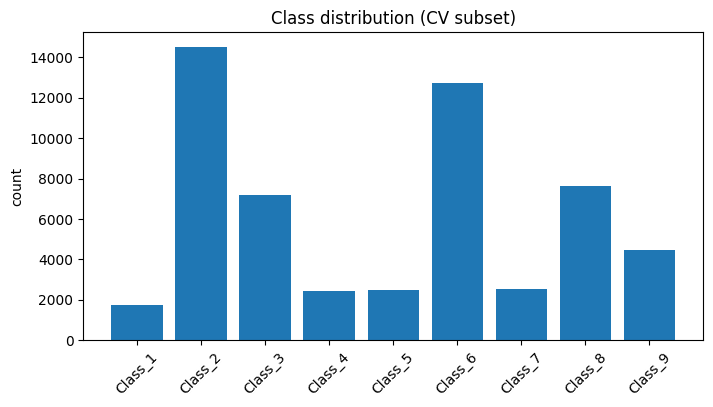

class-prior baseline log loss: 1.9504


In [9]:
import matplotlib.pyplot as plt

y_cv = y[idx_cv]
counts = pd.Series(y_cv).value_counts().sort_index()
counts.index = [int_to_class[i] for i in counts.index]

print(counts)
print("total:", counts.sum())
print("imbalance ratio:", round(counts.max() / counts.min(), 2))

plt.figure(figsize=(8, 4))
plt.bar(counts.index, counts.values)
plt.xticks(rotation=45)
plt.ylabel("count")
plt.title("Class distribution (CV subset)")
plt.show()

priors = np.bincount(y_cv, minlength=9) / len(y_cv)
print("class-prior baseline log loss:", round(my_log_loss(y_cv, np.tile(priors, (len(y_cv), 1))), 5))

In [10]:
X_cv = X.iloc[idx_cv]

print("nulls in train features:", X_cv.isnull().sum().sum())
print("nulls in test features:", X_test.isnull().sum().sum())
print("dtypes:", X_cv.dtypes.value_counts().to_dict())
print("min value:", X_cv.min().min(), "| max value:", X_cv.max().max())
print("any negative:", (X_cv < 0).any().any())

nulls in train features: 0
nulls in test features: 0
dtypes: {dtype('int64'): 93}
min value: 0 | max value: 352
any negative: False


# Sparsity

overall sparsity: 79.31 %

per-feature zero rate:
count    93.000
mean      0.793
std       0.134
min       0.356
25%       0.732
50%       0.831
75%       0.884
max       0.981
dtype: float64

non-zero features per row:
count    55690.00
mean        19.24
std         10.30
min          1.00
25%         11.00
50%         18.00
75%         25.00
max         68.00
dtype: float64


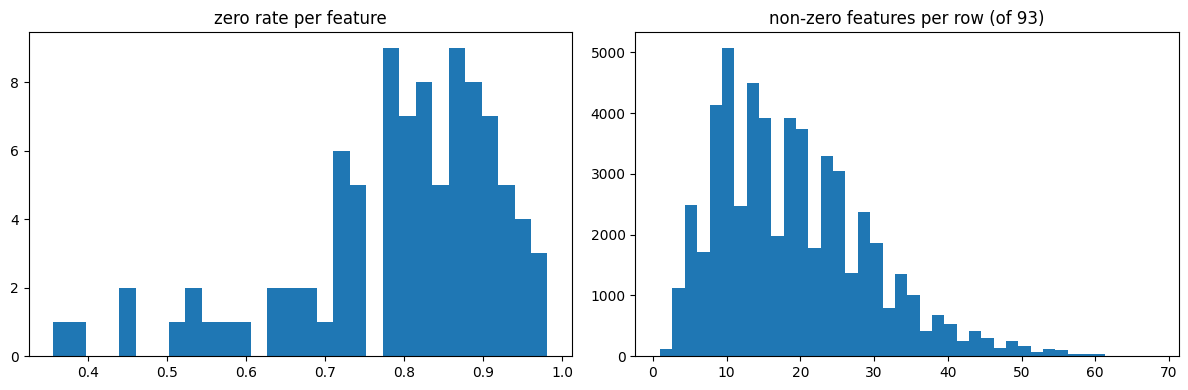

In [11]:
overall_sparsity = (X_cv == 0).values.mean()
print("overall sparsity:", round(overall_sparsity * 100, 2), "%")

zero_rate = (X_cv == 0).mean()
print("\nper-feature zero rate:")
print(zero_rate.describe().round(3))

nonzero_per_row = (X_cv > 0).sum(axis=1)
print("\nnon-zero features per row:")
print(nonzero_per_row.describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(zero_rate.values, bins=30)
axes[0].set_title("zero rate per feature")
axes[1].hist(nonzero_per_row.values, bins=40)
axes[1].set_title("non-zero features per row (of 93)")
plt.tight_layout()
plt.show()

skewness across 93 features:
count    93.00
mean     10.88
std       7.31
min       2.46
25%       5.52
50%       8.94
75%      13.98
max      36.70
dtype: float64

top 5 most skewed:
feat_30    36.70
feat_73    34.86
feat_93    32.38
feat_84    32.19
feat_51    31.65
dtype: float64


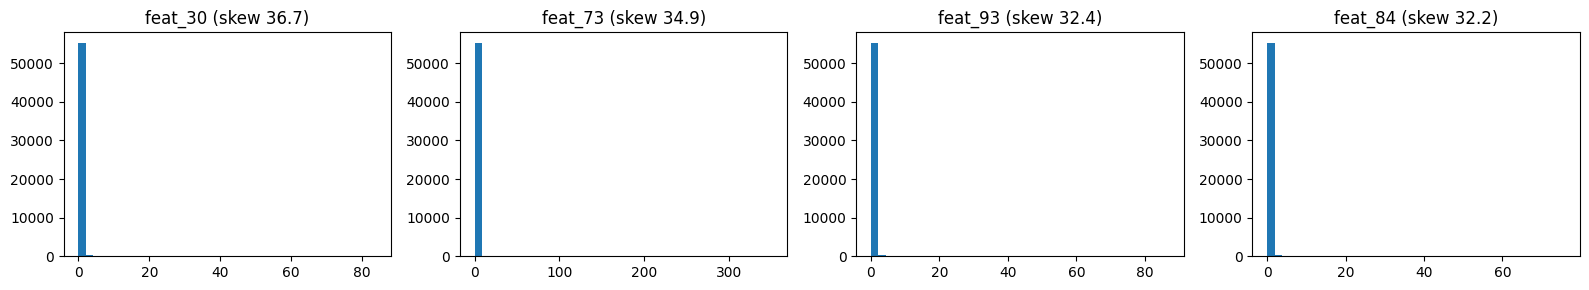

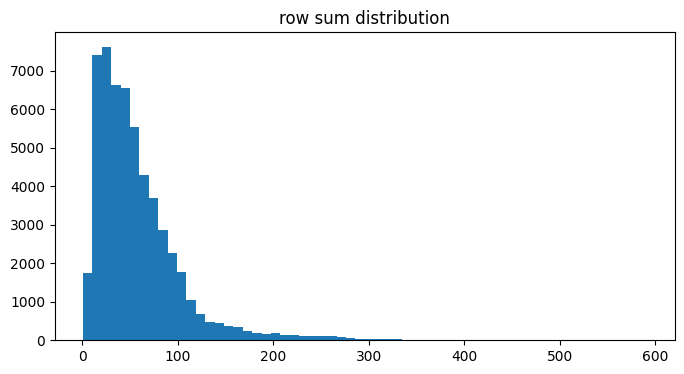

row sum stats:
count    55690.00
mean        58.25
std         47.12
min          1.00
25%         27.00
50%         47.00
75%         75.00
max        591.00
dtype: float64


In [12]:
skews = X_cv.skew().sort_values(ascending=False)
print("skewness across 93 features:")
print(skews.describe().round(2))
print("\ntop 5 most skewed:")
print(skews.head(5).round(2))

top4 = skews.head(4).index
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for ax, col in zip(axes, top4):
    ax.hist(X_cv[col].values, bins=40)
    ax.set_title(f"{col} (skew {X_cv[col].skew():.1f})")
plt.tight_layout()
plt.show()

row_sum = X_cv.sum(axis=1)
plt.figure(figsize=(8, 4))
plt.hist(row_sum.values, bins=60)
plt.title("row sum distribution")
plt.show()
print("row sum stats:")
print(row_sum.describe().round(2))

# Row aggregates by class

/tmp/ipykernel_23/378909065.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[c.replace("Class_", "") for c in CLASS_NAMES], showfliers=False)
/tmp/ipykernel_23/378909065.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[c.replace("Class_", "") for c in CLASS_NAMES], showfliers=False)
/tmp/ipykernel_23/378909065.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[c.replace("Class_", "") for c in CLASS_NAMES], showfliers=False)
/tmp/ipykernel_23/378909065.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been re

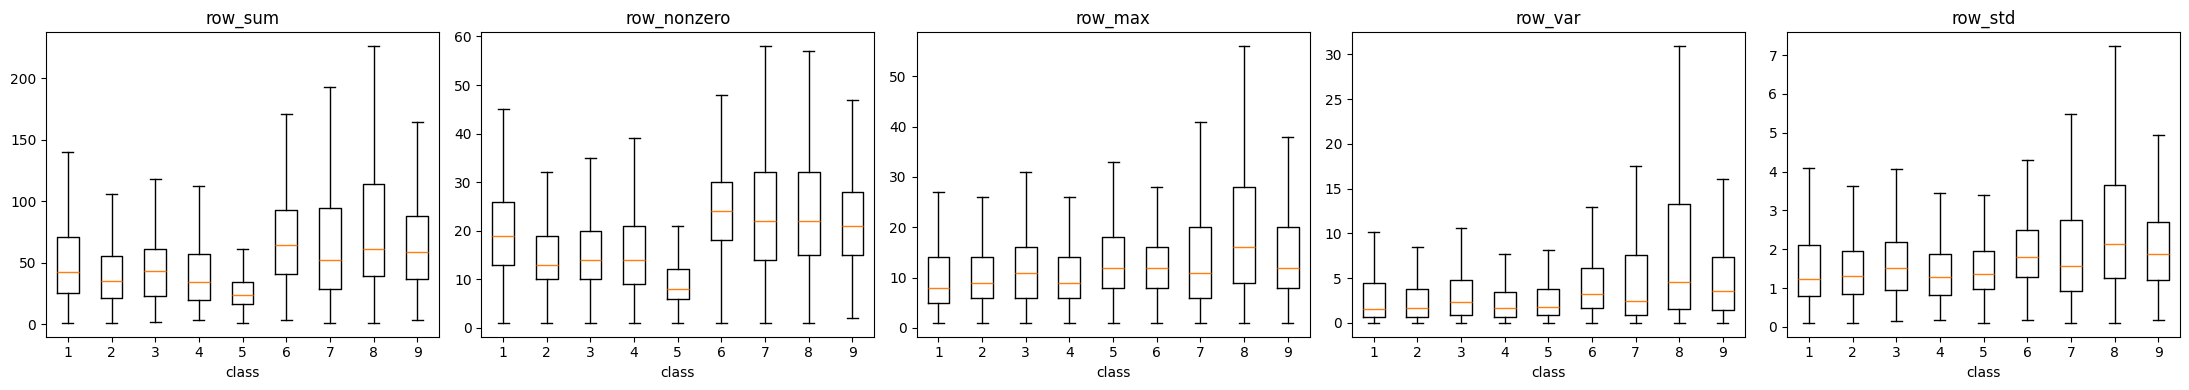

         row_sum  row_nonzero  row_max  row_var  row_std
cls                                                     
Class_1     42.0         19.0      8.0     1.55     1.25
Class_2     35.0         13.0      9.0     1.69     1.30
Class_3     43.0         14.0     11.0     2.29     1.51
Class_4     34.0         14.0      9.0     1.63     1.28
Class_5     24.0          8.0     12.0     1.83     1.35
Class_6     64.0         24.0     12.0     3.22     1.79
Class_7     52.0         22.0     11.0     2.49     1.58
Class_8     61.0         22.0     16.0     4.61     2.15
Class_9     59.0         21.0     12.0     3.55     1.89


In [13]:
aggs = pd.DataFrame({
    "row_sum": X_cv.sum(axis=1).values,
    "row_nonzero": (X_cv > 0).sum(axis=1).values,
    "row_max": X_cv.max(axis=1).values,
    "row_var": X_cv.var(axis=1).values,
    "row_std": X_cv.std(axis=1).values,
})
aggs["cls"] = [int_to_class[i] for i in y_cv]

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, col in zip(axes, ["row_sum", "row_nonzero", "row_max", "row_var", "row_std"]):
    data = [aggs.loc[aggs["cls"] == c, col].values for c in CLASS_NAMES]
    ax.boxplot(data, labels=[c.replace("Class_", "") for c in CLASS_NAMES], showfliers=False)
    ax.set_title(col)
    ax.set_xlabel("class")
plt.tight_layout()
plt.show()

print(aggs.groupby("cls").median().round(2))

# Feature-by-class heatmap

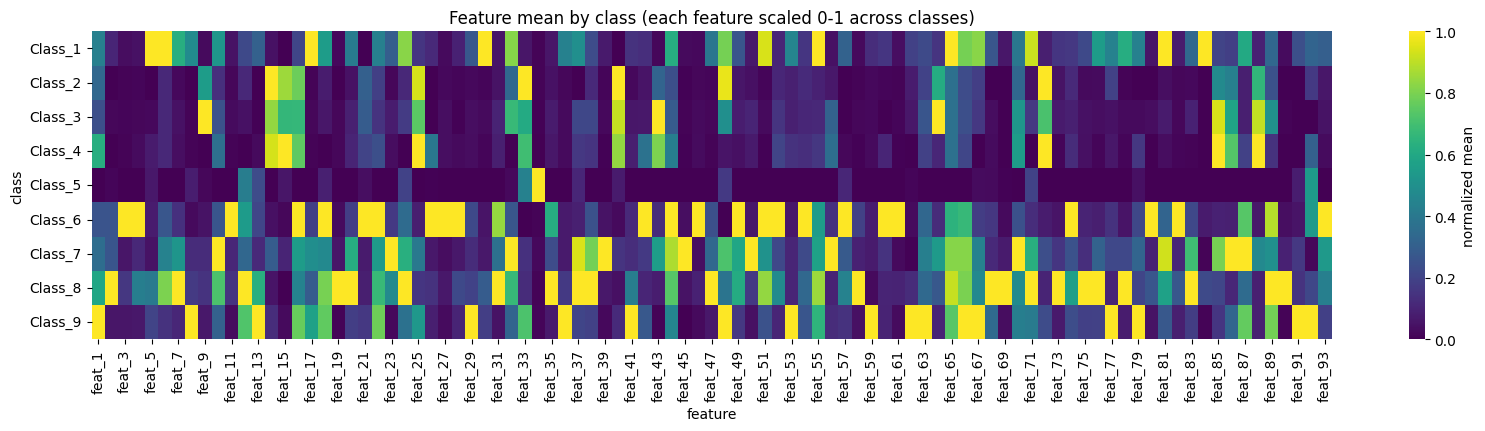

In [14]:
import seaborn as sns

class_means = X_cv.groupby(y_cv).mean()
class_means.index = CLASS_NAMES

normed = (class_means - class_means.min()) / (class_means.max() - class_means.min() + 1e-9)

plt.figure(figsize=(20, 4))
sns.heatmap(normed, cmap="viridis", cbar_kws={"label": "normalized mean"})
plt.title("Feature mean by class (each feature scaled 0-1 across classes)")
plt.xlabel("feature")
plt.ylabel("class")
plt.show()

- Class_5 is nearly all dark.
- Class_6, Class_8, and Class_9 have many bright yellow cells
- Class_2, Class_3, Class_4 look very similar.

We expect t-SNE to show overlapping classes. We've now found them one step early.

# Correlation matrix (Spearman rank correlation)

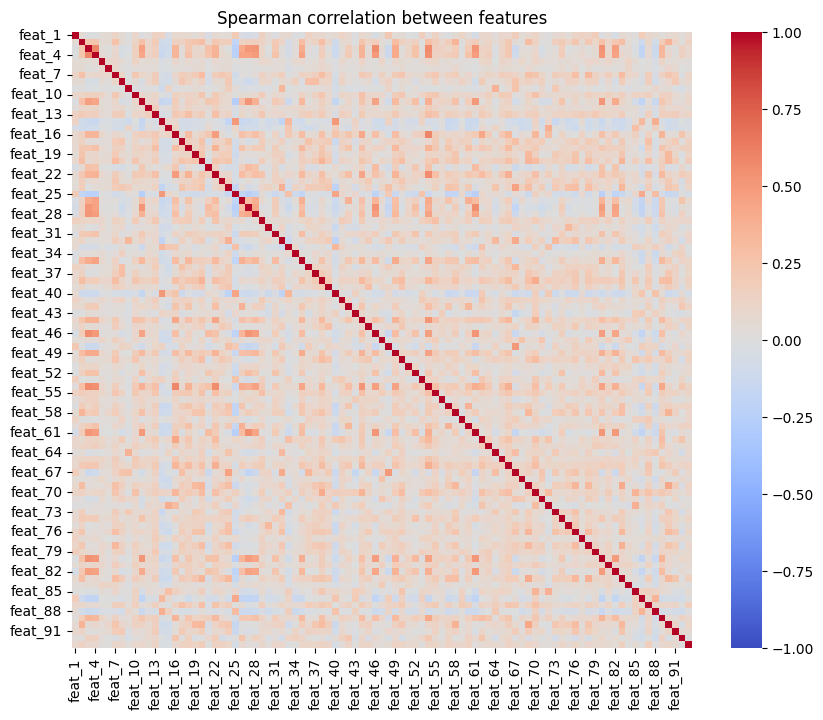

strongest correlated pairs:
feat_16  feat_54    0.592
feat_3   feat_4     0.590
         feat_54    0.566
feat_27  feat_61    0.562
feat_22  feat_54    0.561
feat_3   feat_46    0.560
feat_4   feat_54    0.544
feat_3   feat_80    0.537
feat_27  feat_46    0.527
feat_11  feat_27    0.523
dtype: float64

fraction of pairs with |corr| > 0.5: 0.0047


In [15]:
corr = X_cv.sample(15000, random_state=SEED).corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Spearman correlation between features")
plt.show()

pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
print("strongest correlated pairs:")
print(pairs.abs().sort_values(ascending=False).head(10).round(3))
print("\nfraction of pairs with |corr| > 0.5:", round((pairs.abs() > 0.5).mean(), 4))

There is very little overlap between the 93 features. Almost every feature provides some unique information, so there are no obvious features that can be removed.

# PCA scree plot

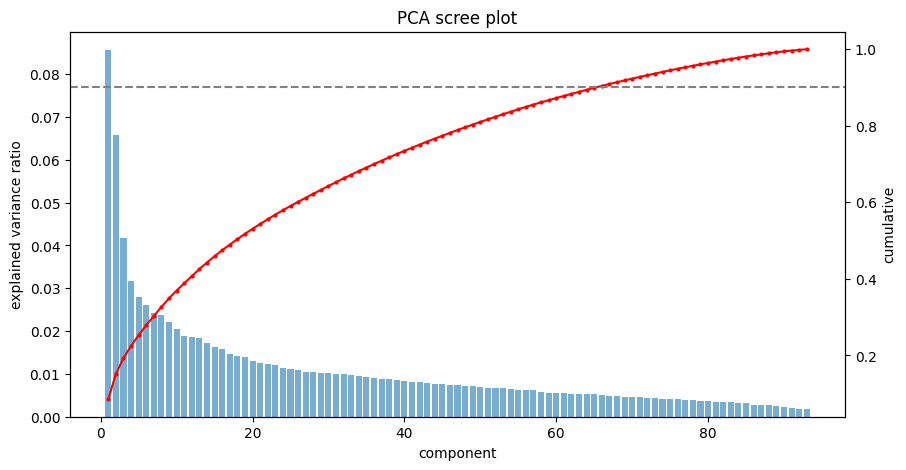

components for 50% variance: 18
components for 80% variance: 49
components for 90% variance: 66
components for 95% variance: 77
first component explains: 8.56 %


In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_scaled = StandardScaler().fit_transform(X_cv)
pca = PCA(n_components=93, random_state=SEED)
pca.fit(X_scaled)

evr = pca.explained_variance_ratio_
cum = np.cumsum(evr)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(range(1, 94), evr, alpha=0.6)
ax1.set_xlabel("component")
ax1.set_ylabel("explained variance ratio")
ax2 = ax1.twinx()
ax2.plot(range(1, 94), cum, color="red", marker="o", markersize=2)
ax2.axhline(0.90, color="gray", linestyle="--")
ax2.set_ylabel("cumulative")
plt.title("PCA scree plot")
plt.show()

for t in [0.50, 0.80, 0.90, 0.95]:
    print(f"components for {int(t*100)}% variance: {np.argmax(cum >= t) + 1}")
print("first component explains:", round(evr[0] * 100, 2), "%")

PCA shows no clear elbow, with 66 out of 93 components needed to retain 90% of the variance, indicating that the data is not easily compressible. Combined with the low feature redundancy observed from Spearman correlation, this suggests that most features contain unique information, so dimensionality reduction is not recommended.

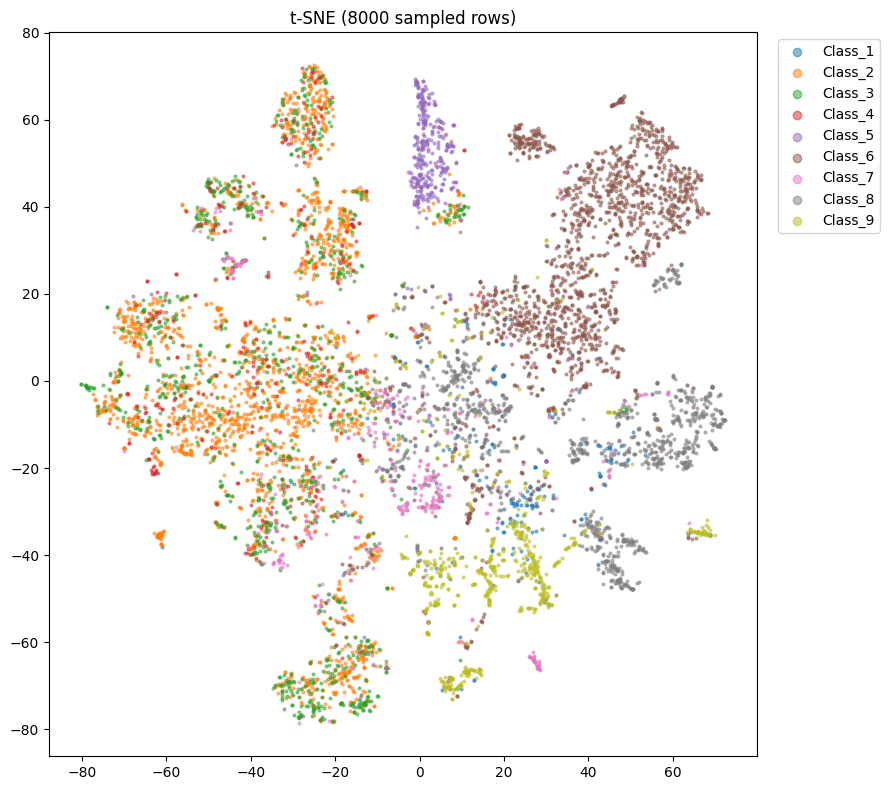

In [17]:
from sklearn.manifold import TSNE

sub_idx = np.random.RandomState(SEED).choice(len(idx_cv), 8000, replace=False)
X_sub = StandardScaler().fit_transform(X_cv.iloc[sub_idx])
y_sub = y_cv[sub_idx]

X_sub_pca = PCA(n_components=30, random_state=SEED).fit_transform(X_sub)
coords = TSNE(n_components=2, perplexity=30, random_state=SEED, init="pca").fit_transform(X_sub_pca)

plt.figure(figsize=(9, 8))
for c in range(9):
    m = y_sub == c
    plt.scatter(coords[m, 0], coords[m, 1], s=4, alpha=0.5, label=int_to_class[c])
plt.legend(markerscale=3, bbox_to_anchor=(1.02, 1))
plt.title("t-SNE (8000 sampled rows)")
plt.tight_layout()
plt.show()

In [18]:
view_A_train = X.copy()
view_A_test = X_test.copy()

print("view A train:", view_A_train.shape)
print("view A test:", view_A_test.shape)

view A train: (61878, 93)
view A test: (144368, 93)


# log + standardized, however we are not standardising here as it needs CV, so we will do it whenever needed

In [19]:
X_log = np.log1p(X)
X_test_log = np.log1p(X_test)

print("skew before:", round(X.skew().median(), 2))
print("skew after:", round(X_log.skew().median(), 2))
print("log view train:", X_log.shape)

skew before: 8.91
skew after: 2.94
log view train: (61878, 93)


# TF-IDF

In [20]:
from sklearn.feature_extraction.text import TfidfTransformer

tfidf = TfidfTransformer(norm="l2", use_idf=True, smooth_idf=True)
tfidf.fit(X.iloc[idx_cv].values)

X_tfidf = tfidf.transform(X.values)
X_test_tfidf = tfidf.transform(X_test.values)

print("tfidf train:", X_tfidf.shape, type(X_tfidf).__name__)
print("tfidf test:", X_test_tfidf.shape)
print("density:", round(X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]) * 100, 2), "%")

tfidf train: (61878, 93) csr_matrix
tfidf test: (144368, 93)
density: 20.66 %


In [21]:
cols = ["feat_24", "feat_42", "feat_60", "feat_67"]
col_pos = [FEATS.index(c) for c in cols]

print("RAW counts:")
print(X[cols].head(3))

print("\nLOG view:")
print(X_log[cols].head(3).round(3))

print("\nTF-IDF view:")
print(pd.DataFrame(X_tfidf[:3, col_pos].toarray(), columns=cols).round(3))

RAW counts:
   feat_24  feat_42  feat_60  feat_67
0        4        5       11        7
1        0        0        0        1
2        0        0        0        6

LOG view:
   feat_24  feat_42  feat_60  feat_67
0    1.609    1.792    2.485    2.079
1    0.000    0.000    0.000    0.693
2    0.000    0.000    0.000    1.946

TF-IDF view:
   feat_24  feat_42  feat_60  feat_67
0    0.166    0.326     0.76    0.301
1    0.000    0.000     0.00    0.146
2    0.000    0.000     0.00    0.757


In [22]:
print("row L2 norms:", np.sqrt(X_tfidf[:3].power(2).sum(axis=1)).ravel())

row L2 norms: [[1. 1. 1.]]


# Aggregate feature block

In [23]:
def add_aggs(df):
    out = df.copy()
    out["row_sum"] = df.sum(axis=1)
    out["row_nonzero"] = (df > 0).sum(axis=1)
    out["row_max"] = df.max(axis=1)
    out["row_std"] = df.std(axis=1)
    return out

view_A_agg_train = add_aggs(X)
view_A_agg_test = add_aggs(X_test)

print("with aggregates:", view_A_agg_train.shape)
print(view_A_agg_train.iloc[:3, -4:])

with aggregates: (61878, 97)
   row_sum  row_nonzero  row_max   row_std
0       51           23       11  1.535919
1       12           10        2  0.396337
2       14            8        6  0.690719


In [24]:
import xgboost as xgb

Xcv_agg = view_A_agg_train.iloc[idx_cv].values
ycv = y[idx_cv]

imp_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    objective="multi:softprob", num_class=9,
    tree_method="hist", random_state=SEED, n_jobs=-1
)
imp_model.fit(Xcv_agg, ycv)

booster = imp_model.get_booster()
booster.feature_names = list(view_A_agg_train.columns)
gain = booster.get_score(importance_type="gain")

imp = pd.Series(gain).sort_values(ascending=False)
print(imp.head(20).round(2))

top10 = [f for f in imp.head(10).index if f in FEATS][:10]
print("\ntop 10 raw features for interactions:", top10)

feat_11    36.12
feat_90    32.54
feat_34    25.82
feat_60    21.27
feat_26    18.55
feat_69    15.75
feat_39    12.20
feat_36    11.60
feat_15    10.45
feat_68    10.32
feat_27    10.24
feat_47     9.87
feat_75     9.64
feat_30     9.57
feat_61     9.28
feat_84     8.97
feat_14     8.60
feat_78     8.14
feat_42     8.00
feat_50     7.22
dtype: float64

top 10 raw features for interactions: ['feat_11', 'feat_90', 'feat_34', 'feat_60', 'feat_26', 'feat_69', 'feat_39', 'feat_36', 'feat_15', 'feat_68']


In [25]:
print(type(imp))

<class 'pandas.core.series.Series'>


In [26]:
import scipy.sparse as sp

W = "/kaggle/working/"

view_A_agg_train.to_parquet(W + "view_A_agg_train.parquet")
view_A_agg_test.to_parquet(W + "view_A_agg_test.parquet")
X_log.to_parquet(W + "X_log.parquet")
X_test_log.to_parquet(W + "X_test_log.parquet")

sp.save_npz(W + "X_tfidf.npz", X_tfidf)
sp.save_npz(W + "X_test_tfidf.npz", X_test_tfidf)

print("saved all views")
print("A:", view_A_agg_train.shape, "| log:", X_log.shape, "| tfidf:", X_tfidf.shape)

saved all views
A: (61878, 97) | log: (61878, 93) | tfidf: (61878, 93)


In [27]:
from sklearn.base import clone
import time

def run_oof(model, Xtr_all, Xte_all, name, scale=False):
    from sklearn.preprocessing import StandardScaler

    Xcv = Xtr_all[idx_cv] if not hasattr(Xtr_all, "iloc") else Xtr_all.iloc[idx_cv].values
    Xho = Xtr_all[idx_holdout] if not hasattr(Xtr_all, "iloc") else Xtr_all.iloc[idx_holdout].values
    Xte = Xte_all if not hasattr(Xte_all, "iloc") else Xte_all.values
    ycv = y[idx_cv]

    oof = np.zeros((len(idx_cv), 9))
    ho_preds = np.zeros((len(idx_holdout), 9))
    te_preds = np.zeros((Xte.shape[0], 9))

    t0 = time.time()
    for f, (tr, va) in enumerate(folds):
        Xa, Xb = Xcv[tr], Xcv[va]
        Xh, Xt = Xho, Xte

        if scale:
            sc = StandardScaler(with_mean=not sp.issparse(Xa))
            Xa = sc.fit_transform(Xa); Xb = sc.transform(Xb)
            Xh = sc.transform(Xho); Xt = sc.transform(Xte)

        m = clone(model)
        m.fit(Xa, ycv[tr])
        oof[va] = m.predict_proba(Xb)
        ho_preds += m.predict_proba(Xh) / len(folds)
        te_preds += m.predict_proba(Xt) / len(folds)
        print(f"  fold {f} done ({time.time()-t0:.0f}s)")

    score = my_log_loss(ycv, oof)
    print(f"{name}: CV log loss = {score:.5f}  [{time.time()-t0:.0f}s]")

    np.save(W + f"oof_{name}.npy", oof)
    np.save(W + f"ho_{name}.npy", ho_preds)
    np.save(W + f"te_{name}.npy", te_preds)
    return oof, ho_preds, te_preds, score

results = {}
print("OOF runner ready")

OOF runner ready


In [28]:
from xgboost import XGBClassifier

xgb_params = dict(
    n_estimators=400,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=9,
    tree_method="hist",
    random_state=SEED,
    n_jobs=-1,
    eval_metric="mlogloss",
)

results["xgb_raw"] = run_oof(
    XGBClassifier(**xgb_params), X, X_test, "xgb_raw"
)[3]

  fold 0 done (30s)
  fold 1 done (59s)
  fold 2 done (89s)
  fold 3 done (119s)
  fold 4 done (149s)
xgb_raw: CV log loss = 0.46982  [149s]


In [29]:
results["xgb_agg"] = run_oof(
    XGBClassifier(**xgb_params), view_A_agg_train, view_A_agg_test, "xgb_agg"
)[3]

print(f"\nraw:  {results['xgb_raw']:.5f}")
print(f"+agg: {results['xgb_agg']:.5f}")
print(f"delta: {results['xgb_agg'] - results['xgb_raw']:+.5f}")

  fold 0 done (31s)
  fold 1 done (62s)
  fold 2 done (93s)
  fold 3 done (125s)
  fold 4 done (156s)
xgb_agg: CV log loss = 0.47322  [156s]

raw:  0.46982
+agg: 0.47322
delta: +0.00340


# Checking if log loss decreased because of new aggregate features or XGB didnt give it much importance

In [30]:
agg_cols = ["row_sum", "row_nonzero", "row_max", "row_std"]

m = XGBClassifier(**xgb_params)
m.fit(view_A_agg_train.iloc[idx_cv], y[idx_cv])

imp = pd.Series(m.feature_importances_, index=view_A_agg_train.columns).sort_values(ascending=False)
print("aggregate ranks out of 97:")
for c in agg_cols:
    print(f"  {c}: rank {list(imp.index).index(c) + 1}, importance {imp[c]:.4f}")
print("\ntop 10 overall:")
print(imp.head(10).round(4))

aggregate ranks out of 97:
  row_sum: rank 71, importance 0.0043
  row_nonzero: rank 53, importance 0.0057
  row_max: rank 64, importance 0.0046
  row_std: rank 69, importance 0.0045

top 10 overall:
feat_11    0.0674
feat_90    0.0600
feat_34    0.0454
feat_60    0.0421
feat_26    0.0346
feat_69    0.0298
feat_39    0.0226
feat_30    0.0200
feat_27    0.0196
feat_36    0.0196
dtype: float32


In [31]:
from sklearn.linear_model import LogisticRegression

results["lr_tfidf"] = run_oof(
    LogisticRegression(C=1.0, max_iter=1000, n_jobs=-1, random_state=SEED),
    X_tfidf, X_test_tfidf, "lr_tfidf"
)[3]

print(f"\nlinear (LR):    {results['lr_tfidf']:.5f}")
print(f"nonlinear (XGB): {results['xgb_raw']:.5f}")
print(f"gap: {results['lr_tfidf'] - results['xgb_raw']:+.5f}")

  fold 0 done (4s)
  fold 1 done (8s)
  fold 2 done (11s)
  fold 3 done (14s)
  fold 4 done (17s)
lr_tfidf: CV log loss = 0.61213  [17s]

linear (LR):    0.61213
nonlinear (XGB): 0.46982
gap: +0.14231


In [32]:
from sklearn.ensemble import RandomForestClassifier

results["rf_raw"] = run_oof(
    RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_leaf=2,
        max_features="sqrt", random_state=SEED, n_jobs=-1
    ),
    X, X_test, "rf_raw"
)[3]

  fold 0 done (15s)
  fold 1 done (29s)
  fold 2 done (43s)
  fold 3 done (58s)
  fold 4 done (72s)
rf_raw: CV log loss = 0.59782  [72s]


In [33]:
from sklearn.ensemble import ExtraTreesClassifier

results["et_raw"] = run_oof(
    ExtraTreesClassifier(
        n_estimators=300, max_depth=None, min_samples_leaf=2,
        max_features="sqrt", random_state=SEED, n_jobs=-1
    ),
    X, X_test, "et_raw"
)[3]

  fold 0 done (16s)
  fold 1 done (32s)
  fold 2 done (48s)
  fold 3 done (63s)
  fold 4 done (79s)
et_raw: CV log loss = 0.62687  [79s]


In [34]:
from sklearn.neighbors import KNeighborsClassifier

for k in [2, 4, 8, 16, 32]:
    name = f"knn{k}_tfidf"
    results[name] = run_oof(
        KNeighborsClassifier(n_neighbors=k, metric="euclidean", n_jobs=-1),
        X_tfidf, X_test_tfidf, name
    )[3]

print("\nKNN summary:")
for k in [2, 4, 8, 16, 32]:
    print(f"  k={k:2d}: {results[f'knn{k}_tfidf']:.5f}")

  fold 0 done (262s)
  fold 1 done (527s)
  fold 2 done (794s)
  fold 3 done (1059s)
  fold 4 done (1323s)
knn2_tfidf: CV log loss = 4.82969  [1323s]
  fold 0 done (263s)
  fold 1 done (530s)
  fold 2 done (794s)
  fold 3 done (1060s)
  fold 4 done (1324s)
knn4_tfidf: CV log loss = 2.88902  [1324s]
  fold 0 done (268s)
  fold 1 done (537s)
  fold 2 done (807s)
  fold 3 done (1076s)
  fold 4 done (1345s)
knn8_tfidf: CV log loss = 1.82364  [1345s]
  fold 0 done (267s)
  fold 1 done (536s)
  fold 2 done (805s)
  fold 3 done (1075s)
  fold 4 done (1343s)
knn16_tfidf: CV log loss = 1.26217  [1343s]
  fold 0 done (268s)
  fold 1 done (537s)
  fold 2 done (806s)
  fold 3 done (1074s)
  fold 4 done (1343s)
knn32_tfidf: CV log loss = 0.96812  [1343s]

KNN summary:
  k= 2: 4.82969
  k= 4: 2.88902
  k= 8: 1.82364
  k=16: 1.26217
  k=32: 0.96812


In [35]:
results["xgb_tfidf"] = run_oof(
    XGBClassifier(**xgb_params), X_tfidf, X_test_tfidf, "xgb_tfidf"
)[3]

oof_a = np.load(W + "oof_xgb_raw.npy")
oof_b = np.load(W + "oof_xgb_tfidf.npy")
corr = np.mean([np.corrcoef(oof_a[:, c], oof_b[:, c])[0, 1] for c in range(9)])

print(f"\nxgb_raw:   {results['xgb_raw']:.5f}")
print(f"xgb_tfidf: {results['xgb_tfidf']:.5f}")
print(f"correlation: {corr:.4f}")

  fold 0 done (102s)
  fold 1 done (203s)
  fold 2 done (303s)
  fold 3 done (405s)
  fold 4 done (506s)
xgb_tfidf: CV log loss = 0.48989  [506s]

xgb_raw:   0.46982
xgb_tfidf: 0.48989
correlation: 0.9635


In [36]:
from sklearn.neural_network import MLPClassifier

results["mlp_log"] = run_oof(
    MLPClassifier(
        hidden_layer_sizes=(256, 128),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        batch_size=256,
        learning_rate_init=1e-3,
        max_iter=60,
        early_stopping=True,
        n_iter_no_change=8,
        validation_fraction=0.1,
        random_state=SEED,
    ),
    X_log, X_test_log, "mlp_log", scale=True
)[3]

  fold 0 done (22s)
  fold 1 done (35s)
  fold 2 done (54s)
  fold 3 done (66s)
  fold 4 done (79s)
mlp_log: CV log loss = 0.56403  [79s]


In [37]:
oof_mlp = np.load(W + "oof_mlp_log.npy")
oof_xgb = np.load(W + "oof_xgb_raw.npy")
corr = np.mean([np.corrcoef(oof_mlp[:, c], oof_xgb[:, c])[0, 1] for c in range(9)])
print(f"mlp vs xgb correlation: {corr:.4f}")

mlp vs xgb correlation: 0.9203


# Using PCA for new KNN features as it was very very slow last time

In [38]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=50, random_state=SEED)
svd.fit(X_tfidf[idx_cv])

Xcv_t = svd.transform(X_tfidf[idx_cv])
Xho_t = svd.transform(X_tfidf[idx_holdout])
Xte_t = svd.transform(X_test_tfidf)

print("reduced:", Xcv_t.shape, "| variance explained:", round(svd.explained_variance_ratio_.sum(), 4))

reduced: (55690, 50) | variance explained: 0.8753


# Pretty good variance captured as compared to what it captured earlier, this change happened because TF-IDF fixed the scale

# Extra KNN nearest class features

In [39]:
from sklearn.neighbors import NearestNeighbors
import time

K_DIST = 5
ycv = y[idx_cv]

dist_oof = np.zeros((len(idx_cv), 9))
dist_ho = np.zeros((len(idx_holdout), 9))
dist_te = np.zeros((Xte_t.shape[0], 9))

t0 = time.time()
for f, (tr, va) in enumerate(folds):
    for c in range(9):
        Xc = Xcv_t[tr][ycv[tr] == c]
        nn = NearestNeighbors(n_neighbors=min(K_DIST, len(Xc)), n_jobs=-1).fit(Xc)
        dist_oof[va, c] = nn.kneighbors(Xcv_t[va])[0].mean(axis=1)
        dist_ho[:, c] += nn.kneighbors(Xho_t)[0].mean(axis=1) / len(folds)
        dist_te[:, c] += nn.kneighbors(Xte_t)[0].mean(axis=1) / len(folds)
    print(f"  fold {f} done ({time.time()-t0:.0f}s)")

np.save(W + "oof_knndist.npy", dist_oof)
np.save(W + "ho_knndist.npy", dist_ho)
np.save(W + "te_knndist.npy", dist_te)

print("\nmean distance to each class, rows = true class:")
print(pd.DataFrame(dist_oof).groupby(ycv).mean().round(3))

  fold 0 done (24s)
  fold 1 done (48s)
  fold 2 done (72s)
  fold 3 done (96s)
  fold 4 done (121s)

mean distance to each class, rows = true class:
       0      1      2      3      4      5      6      7      8
0  0.452  0.710  0.760  0.798  0.868  0.568  0.634  0.572  0.551
1  0.806  0.324  0.380  0.460  0.817  0.775  0.625  0.777  0.815
2  0.798  0.335  0.326  0.449  0.807  0.718  0.564  0.747  0.831
3  0.797  0.407  0.426  0.392  0.920  0.788  0.635  0.854  0.827
4  0.816  0.370  0.593  0.395  0.179  0.787  0.590  0.668  0.721
5  0.716  0.819  0.869  0.791  0.975  0.314  0.696  0.622  0.686
6  0.686  0.607  0.618  0.685  0.951  0.515  0.409  0.675  0.721
7  0.618  0.786  0.838  0.913  0.981  0.557  0.661  0.286  0.674
8  0.492  0.745  0.794  0.847  0.899  0.517  0.739  0.666  0.324


In [40]:
MODELS = ["xgb_raw", "xgb_tfidf", "rf_raw", "et_raw", "lr_tfidf", "mlp_log",
          "knn2_tfidf", "knn4_tfidf", "knn8_tfidf", "knn16_tfidf", "knn32_tfidf",
          "knndist"]

meta_cv = np.hstack([np.load(W + f"oof_{m}.npy") for m in MODELS])
meta_ho = np.hstack([np.load(W + f"ho_{m}.npy") for m in MODELS])
meta_te = np.hstack([np.load(W + f"te_{m}.npy") for m in MODELS])

L2_cv = np.hstack([meta_cv, X.iloc[idx_cv].values])
L2_ho = np.hstack([meta_ho, X.iloc[idx_holdout].values])
L2_te = np.hstack([meta_te, X_test.values])

print("meta only:", meta_cv.shape)
print("L2 train:", L2_cv.shape)
print("L2 holdout:", L2_ho.shape)
print("L2 test:", L2_te.shape)

meta only: (55690, 108)
L2 train: (55690, 201)
L2 holdout: (6188, 201)
L2 test: (144368, 201)


# Checking unique signal of KNN k=2 TFIDF, if we should keep it or not since its log loss was terrible

In [41]:
oof_k2 = np.load(W + "oof_knn2_tfidf.npy")
for other in ["knn4_tfidf", "knn8_tfidf", "knn32_tfidf"]:
    o = np.load(W + f"oof_{other}.npy")
    c = np.mean([np.corrcoef(oof_k2[:, i], o[:, i])[0, 1] for i in range(9)])
    print(f"knn2 vs {other}: {c:.4f}")

knn2 vs knn4_tfidf: 0.9409
knn2 vs knn8_tfidf: 0.9014
knn2 vs knn32_tfidf: 0.8498


# Level-2 (Meta-Model)

In [42]:
l2_params = dict(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=9,
    tree_method="hist",
    random_state=SEED,
    n_jobs=-1,
    eval_metric="mlogloss",
)

ycv = y[idx_cv]
oof_l2 = np.zeros((len(idx_cv), 9))
ho_l2 = np.zeros((len(idx_holdout), 9))
te_l2 = np.zeros((L2_te.shape[0], 9))

for f, (tr, va) in enumerate(folds):
    m = XGBClassifier(**l2_params)
    m.fit(L2_cv[tr], ycv[tr])
    oof_l2[va] = m.predict_proba(L2_cv[va])
    ho_l2 += m.predict_proba(L2_ho) / len(folds)
    te_l2 += m.predict_proba(L2_te) / len(folds)
    print(f"  fold {f} done")

score_l2 = my_log_loss(ycv, oof_l2)
np.save(W + "oof_l2_xgb.npy", oof_l2)
np.save(W + "ho_l2_xgb.npy", ho_l2)
np.save(W + "te_l2_xgb.npy", te_l2)

print(f"\nlevel 2 XGBoost: {score_l2:.5f}")
print(f"best level 1 (xgb_raw): {results['xgb_raw']:.5f}")
print(f"improvement: {score_l2 - results['xgb_raw']:+.5f}")

  fold 0 done
  fold 1 done
  fold 2 done
  fold 3 done
  fold 4 done

level 2 XGBoost: 0.43828
best level 1 (xgb_raw): 0.46982
improvement: -0.03154


# Manual Grid Search for XGB, didn't use automatic gridseachCV as it forms its own folds

In [43]:
tr0, va0 = folds[0]
grid = [(d, lr) for d in [3, 4, 5, 6] for lr in [0.05, 0.1]]
tune = []

for d, lr in grid:
    p = dict(l2_params)
    p.update(max_depth=d, learning_rate=lr, n_estimators=2000,
             early_stopping_rounds=30)
    m = XGBClassifier(**p)
    m.fit(L2_cv[tr0], ycv[tr0],
          eval_set=[(L2_cv[va0], ycv[va0])], verbose=False)
    s = my_log_loss(ycv[va0], m.predict_proba(L2_cv[va0]))
    tune.append((d, lr, m.best_iteration, s))
    print(f"depth={d} lr={lr}: {s:.5f}  (best_iter={m.best_iteration})")

tune_df = pd.DataFrame(tune, columns=["depth", "lr", "best_iter", "logloss"]).sort_values("logloss")
print("\nranked:")
print(tune_df.to_string(index=False))

depth=3 lr=0.05: 0.43722  (best_iter=247)
depth=3 lr=0.1: 0.43876  (best_iter=119)
depth=4 lr=0.05: 0.43700  (best_iter=198)
depth=4 lr=0.1: 0.43917  (best_iter=102)
depth=5 lr=0.05: 0.43876  (best_iter=187)
depth=5 lr=0.1: 0.44048  (best_iter=92)
depth=6 lr=0.05: 0.44247  (best_iter=166)
depth=6 lr=0.1: 0.44407  (best_iter=84)

ranked:
 depth   lr  best_iter  logloss
     4 0.05        198 0.436997
     3 0.05        247 0.437215
     5 0.05        187 0.438756
     3 0.10        119 0.438757
     4 0.10        102 0.439169
     5 0.10         92 0.440485
     6 0.05        166 0.442466
     6 0.10         84 0.444069


# Final XGB with 280 trees

In [44]:
l2_tuned = dict(l2_params)
l2_tuned.update(max_depth=3, learning_rate=0.05, n_estimators=280)

oof_l2 = np.zeros((len(idx_cv), 9))
ho_l2 = np.zeros((len(idx_holdout), 9))
te_l2 = np.zeros((L2_te.shape[0], 9))

for f, (tr, va) in enumerate(folds):
    m = XGBClassifier(**l2_tuned)
    m.fit(L2_cv[tr], ycv[tr])
    oof_l2[va] = m.predict_proba(L2_cv[va])
    ho_l2 += m.predict_proba(L2_ho) / len(folds)
    te_l2 += m.predict_proba(L2_te) / len(folds)
    print(f"  fold {f} done")

score_l2_tuned = my_log_loss(ycv, oof_l2)
np.save(W + "oof_l2_xgb.npy", oof_l2)
np.save(W + "ho_l2_xgb.npy", ho_l2)
np.save(W + "te_l2_xgb.npy", te_l2)

print(f"\nuntuned (d4, lr.05, 500 trees): {score_l2:.5f}")
print(f"tuned   (d3, lr.05, 280 trees): {score_l2_tuned:.5f}")
print(f"delta: {score_l2_tuned - score_l2:+.5f}")

  fold 0 done
  fold 1 done
  fold 2 done
  fold 3 done
  fold 4 done

untuned (d4, lr.05, 500 trees): 0.43828
tuned   (d3, lr.05, 280 trees): 0.43183
delta: -0.00645


# Checking if KNN actually improved ensemble

In [45]:
NO_KNN = ["xgb_raw", "xgb_tfidf", "rf_raw", "et_raw", "lr_tfidf", "mlp_log"]

mcv = np.hstack([np.load(W + f"oof_{m}.npy") for m in NO_KNN])
L2_cv_nk = np.hstack([mcv, X.iloc[idx_cv].values])

oof_nk = np.zeros((len(idx_cv), 9))
for f, (tr, va) in enumerate(folds):
    m = XGBClassifier(**l2_tuned)
    m.fit(L2_cv_nk[tr], ycv[tr])
    oof_nk[va] = m.predict_proba(L2_cv_nk[va])

score_nk = my_log_loss(ycv, oof_nk)
print(f"with KNN block:    {score_l2_tuned:.5f}")
print(f"without KNN block: {score_nk:.5f}")
print(f"KNN contribution:  {score_l2_tuned - score_nk:+.5f}")

with KNN block:    0.43183
without KNN block: 0.44050
KNN contribution:  -0.00867


# XGB bagging with 10 random seeds

In [46]:
N_BAGS = 10
oof_bag = np.zeros((len(idx_cv), 9))
ho_bag = np.zeros((len(idx_holdout), 9))
te_bag = np.zeros((L2_te.shape[0], 9))

for b in range(N_BAGS):
    p = dict(l2_tuned)
    p.update(random_state=SEED + b * 100)
    for f, (tr, va) in enumerate(folds):
        m = XGBClassifier(**p)
        m.fit(L2_cv[tr], ycv[tr])
        oof_bag[va] += m.predict_proba(L2_cv[va]) / N_BAGS
        ho_bag += m.predict_proba(L2_ho) / (N_BAGS * len(folds))
        te_bag += m.predict_proba(L2_te) / (N_BAGS * len(folds))
    print(f"bag {b}: running score {my_log_loss(ycv, oof_bag * N_BAGS / (b + 1)):.5f}")

score_bag = my_log_loss(ycv, oof_bag)
np.save(W + "oof_l2_xgb_bag.npy", oof_bag)
np.save(W + "ho_l2_xgb_bag.npy", ho_bag)
np.save(W + "te_l2_xgb_bag.npy", te_bag)

print(f"\nsingle seed: {score_l2_tuned:.5f}")
print(f"10-seed bag: {score_bag:.5f}")
print(f"delta: {score_bag - score_l2_tuned:+.5f}")

bag 0: running score 0.43183
bag 1: running score 0.43164
bag 2: running score 0.43151
bag 3: running score 0.43144
bag 4: running score 0.43139
bag 5: running score 0.43134
bag 6: running score 0.43133
bag 7: running score 0.43131
bag 8: running score 0.43128
bag 9: running score 0.43130

single seed: 0.43183
10-seed bag: 0.43130
delta: -0.00053


# MLP level 2

In [47]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

oof_l2nn = np.zeros((len(idx_cv), 9))
ho_l2nn = np.zeros((len(idx_holdout), 9))
te_l2nn = np.zeros((L2_te.shape[0], 9))

for f, (tr, va) in enumerate(folds):
    sc = StandardScaler()
    Xa = sc.fit_transform(L2_cv[tr])
    Xb = sc.transform(L2_cv[va])
    Xh = sc.transform(L2_ho)
    Xt = sc.transform(L2_te)

    m = MLPClassifier(hidden_layer_sizes=(256, 128), alpha=1e-3, batch_size=256,
                      learning_rate_init=1e-3, max_iter=60, early_stopping=True,
                      n_iter_no_change=8, random_state=SEED)
    m.fit(Xa, ycv[tr])
    oof_l2nn[va] = m.predict_proba(Xb)
    ho_l2nn += m.predict_proba(Xh) / len(folds)
    te_l2nn += m.predict_proba(Xt) / len(folds)
    print(f"  fold {f} done")

score_l2nn = my_log_loss(ycv, oof_l2nn)
np.save(W + "oof_l2_nn.npy", oof_l2nn)
np.save(W + "ho_l2_nn.npy", ho_l2nn)
np.save(W + "te_l2_nn.npy", te_l2nn)

print(f"\nlevel 2 NN:  {score_l2nn:.5f}")
print(f"level 2 XGB: {score_l2_tuned:.5f}")

  fold 0 done
  fold 1 done
  fold 2 done
  fold 3 done
  fold 4 done

level 2 NN:  0.45911
level 2 XGB: 0.43183


In [48]:
o_x = np.load(W + "oof_l2_xgb_bag.npy")
o_n = np.load(W + "oof_l2_nn.npy")
c = np.mean([np.corrcoef(o_x[:, i], o_n[:, i])[0, 1] for i in range(9)])
print(f"L2 XGB vs L2 NN correlation: {c:.4f}")

L2 XGB vs L2 NN correlation: 0.9823


In [49]:
from sklearn.linear_model import LogisticRegression

oof_l2lr = np.zeros((len(idx_cv), 9))
ho_l2lr = np.zeros((len(idx_holdout), 9))
te_l2lr = np.zeros((L2_te.shape[0], 9))

for f, (tr, va) in enumerate(folds):
    m = LogisticRegression(C=1.0, max_iter=1000, n_jobs=-1, random_state=SEED)
    m.fit(meta_cv[tr], ycv[tr])
    oof_l2lr[va] = m.predict_proba(meta_cv[va])
    ho_l2lr += m.predict_proba(meta_ho) / len(folds)
    te_l2lr += m.predict_proba(meta_te) / len(folds)

score_l2lr = my_log_loss(ycv, oof_l2lr)
np.save(W + "oof_l2_lr.npy", oof_l2lr)
np.save(W + "ho_l2_lr.npy", ho_l2lr)
np.save(W + "te_l2_lr.npy", te_l2lr)

o_x = np.load(W + "oof_l2_xgb_bag.npy")
c = np.mean([np.corrcoef(o_x[:, i], oof_l2lr[:, i])[0, 1] for i in range(9)])
print(f"L2 LR: {score_l2lr:.5f} | correlation with L2 XGB: {c:.4f}")

L2 LR: 0.44884 | correlation with L2 XGB: 0.9892


In [50]:
from sklearn.ensemble import AdaBoostClassifier, ExtraTreesClassifier

base_et = ExtraTreesClassifier(n_estimators=30, max_depth=6, max_features="sqrt",
                               random_state=SEED, n_jobs=-1)

oof_ada = np.zeros((len(idx_cv), 9))
ho_ada = np.zeros((len(idx_holdout), 9))
te_ada = np.zeros((L2_te.shape[0], 9))

for f, (tr, va) in enumerate(folds):
    m = AdaBoostClassifier(estimator=base_et, n_estimators=20,
                           learning_rate=0.5, random_state=SEED)
    m.fit(L2_cv[tr], ycv[tr])
    oof_ada[va] = m.predict_proba(L2_cv[va])
    ho_ada += m.predict_proba(L2_ho) / len(folds)
    te_ada += m.predict_proba(L2_te) / len(folds)
    print(f"  fold {f} done")

score_ada = my_log_loss(ycv, oof_ada)
np.save(W + "oof_l2_ada.npy", oof_ada)
np.save(W + "ho_l2_ada.npy", ho_ada)
np.save(W + "te_l2_ada.npy", te_ada)

o_x = np.load(W + "oof_l2_xgb_bag.npy")
c = np.mean([np.corrcoef(o_x[:, i], oof_ada[:, i])[0, 1] for i in range(9)])
print(f"\nL2 AdaBoost+ET: {score_ada:.5f} | correlation with L2 XGB: {c:.4f}")

  fold 0 done
  fold 1 done
  fold 2 done
  fold 3 done
  fold 4 done

L2 AdaBoost+ET: 2.14194 | correlation with L2 XGB: 0.8514


In [51]:
import lightgbm as lgb

lgb_params = dict(
    objective="multiclass",
    num_class=9,
    n_estimators=300,
    num_leaves=15,
    learning_rate=0.05,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    min_child_samples=30,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
)

oof_lgb = np.zeros((len(idx_cv), 9))
ho_lgb = np.zeros((len(idx_holdout), 9))
te_lgb = np.zeros((L2_te.shape[0], 9))

for f, (tr, va) in enumerate(folds):
    m = lgb.LGBMClassifier(**lgb_params)
    m.fit(L2_cv[tr], ycv[tr])
    oof_lgb[va] = m.predict_proba(L2_cv[va])
    ho_lgb += m.predict_proba(L2_ho) / len(folds)
    te_lgb += m.predict_proba(L2_te) / len(folds)
    print(f"  fold {f} done")

score_lgb = my_log_loss(ycv, oof_lgb)
np.save(W + "oof_l2_lgb.npy", oof_lgb)
np.save(W + "ho_l2_lgb.npy", ho_lgb)
np.save(W + "te_l2_lgb.npy", te_lgb)

o_x = np.load(W + "oof_l2_xgb_bag.npy")
c = np.mean([np.corrcoef(o_x[:, i], oof_lgb[:, i])[0, 1] for i in range(9)])
print(f"\nL2 LightGBM: {score_lgb:.5f} | correlation with L2 XGB: {c:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  fold 0 done


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  fold 1 done


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  fold 2 done


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  fold 3 done


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  fold 4 done

L2 LightGBM: 0.44898 | correlation with L2 XGB: 0.9932


In [52]:
from sklearn.naive_bayes import GaussianNB

oof_nb = np.zeros((len(idx_cv), 9))
ho_nb = np.zeros((len(idx_holdout), 9))
te_nb = np.zeros((L2_te.shape[0], 9))

for f, (tr, va) in enumerate(folds):
    m = GaussianNB(var_smoothing=1e-6)
    m.fit(meta_cv[tr], ycv[tr])
    oof_nb[va] = m.predict_proba(meta_cv[va])
    ho_nb += m.predict_proba(meta_ho) / len(folds)
    te_nb += m.predict_proba(meta_te) / len(folds)
    print(f"  fold {f} done")

score_nb = my_log_loss(ycv, oof_nb)
np.save(W + "oof_l2_nb.npy", oof_nb)
np.save(W + "ho_l2_nb.npy", ho_nb)
np.save(W + "te_l2_nb.npy", te_nb)

o_x = np.load(W + "oof_l2_xgb_bag.npy")
c = np.mean([np.corrcoef(o_x[:, i], oof_nb[:, i])[0, 1] for i in range(9)])
acc = (oof_nb.argmax(1) == ycv).mean()
print(f"\nL2 NaiveBayes: {score_nb:.5f} | corr: {c:.4f} | top-1 accuracy: {acc:.4f}")

  fold 0 done
  fold 1 done
  fold 2 done
  fold 3 done
  fold 4 done

L2 NaiveBayes: 4.98830 | corr: 0.8885 | top-1 accuracy: 0.7980


# Manual Hyper opti for NN

In [53]:
tr0, va0 = folds[0]
sc = StandardScaler()
Xa = sc.fit_transform(L2_cv[tr0])
Xb = sc.transform(L2_cv[va0])

configs = [
    ((128,),      1e-3, 1e-3),
    ((256, 128),  1e-3, 1e-3),
    ((256, 128),  1e-2, 1e-3),
    ((512, 256),  1e-3, 1e-3),
    ((256, 128),  1e-3, 3e-4),
    ((512, 256, 128), 1e-2, 1e-3),
]

for hl, alpha, lr in configs:
    m = MLPClassifier(hidden_layer_sizes=hl, alpha=alpha, batch_size=256,
                      learning_rate_init=lr, max_iter=100, early_stopping=True,
                      n_iter_no_change=12, validation_fraction=0.1, random_state=SEED)
    m.fit(Xa, ycv[tr0])
    s = my_log_loss(ycv[va0], m.predict_proba(Xb))
    print(f"{str(hl):18s} alpha={alpha:<6} lr={lr:<6}: {s:.5f}  (epochs={m.n_iter_})")

(128,)             alpha=0.001  lr=0.001 : 0.45702  (epochs=16)
(256, 128)         alpha=0.001  lr=0.001 : 0.48465  (epochs=24)
(256, 128)         alpha=0.01   lr=0.001 : 0.46072  (epochs=18)
(512, 256)         alpha=0.001  lr=0.001 : 0.46601  (epochs=14)
(256, 128)         alpha=0.001  lr=0.0003: 0.45795  (epochs=28)
(512, 256, 128)    alpha=0.01   lr=0.001 : 0.46310  (epochs=15)


# Final 1 layer 128, alpha= 1e-3 and lr = 1e-3

In [54]:
oof_nn2 = np.zeros((len(idx_cv), 9))
ho_nn2 = np.zeros((len(idx_holdout), 9))
te_nn2 = np.zeros((L2_te.shape[0], 9))
N_BAGS = 10

for b in range(N_BAGS):
    for f, (tr, va) in enumerate(folds):
        sc = StandardScaler()
        Xa = sc.fit_transform(L2_cv[tr]); Xb = sc.transform(L2_cv[va])
        Xh = sc.transform(L2_ho); Xt = sc.transform(L2_te)
        m = MLPClassifier(hidden_layer_sizes=(128,), alpha=1e-3, batch_size=256,
                          learning_rate_init=1e-3, max_iter=100, early_stopping=True,
                          n_iter_no_change=12, random_state=SEED + b * 100)
        m.fit(Xa, ycv[tr])
        oof_nn2[va] += m.predict_proba(Xb) / N_BAGS
        ho_nn2 += m.predict_proba(Xh) / (N_BAGS * len(folds))
        te_nn2 += m.predict_proba(Xt) / (N_BAGS * len(folds))
    print(f"bag {b}: {my_log_loss(ycv, oof_nn2 * N_BAGS / (b + 1)):.5f}")

score_nn2 = my_log_loss(ycv, oof_nn2)
np.save(W + "oof_l2_nn_bag.npy", oof_nn2)
np.save(W + "ho_l2_nn_bag.npy", ho_nn2)
np.save(W + "te_l2_nn_bag.npy", te_nn2)

o_x = np.load(W + "oof_l2_xgb_bag.npy")
c = np.mean([np.corrcoef(o_x[:, i], oof_nn2[:, i])[0, 1] for i in range(9)])
print(f"\ntuned+bagged NN: {score_nn2:.5f} | untuned single: {score_l2nn:.5f} | corr: {c:.4f}")

bag 0: 0.44934
bag 1: 0.44306
bag 2: 0.44038
bag 3: 0.43886
bag 4: 0.43809
bag 5: 0.43746
bag 6: 0.43700
bag 7: 0.43681
bag 8: 0.43635
bag 9: 0.43620

tuned+bagged NN: 0.43620 | untuned single: 0.45911 | corr: 0.9916


# Trying for 1e-4 lr instead of 1e-3

In [55]:
tr0, va0 = folds[0]
sc0 = StandardScaler()
Xa = sc0.fit_transform(L2_cv[tr0])
Xb = sc0.transform(L2_cv[va0])

print("Xa mean/std:", round(Xa.mean(), 4), round(Xa.std(), 4))
print("Xb mean/std:", round(Xb.mean(), 4), round(Xb.std(), 4))

for hl, lr in [((128,), 3e-4), ((128,), 1e-4), ((256, 128), 1e-4)]:
    m = MLPClassifier(hidden_layer_sizes=hl, alpha=1e-3, batch_size=256,
                      learning_rate_init=lr, max_iter=300, early_stopping=True,
                      n_iter_no_change=20, random_state=SEED)
    m.fit(Xa, ycv[tr0])
    print(f"{str(hl):12s} lr={lr}: {my_log_loss(ycv[va0], m.predict_proba(Xb)):.5f} (epochs={m.n_iter_})")

Xa mean/std: -0.0 1.0
Xb mean/std: -0.0007 1.0077
(128,)       lr=0.0003: 0.45236 (epochs=35)
(128,)       lr=0.0001: 0.45480 (epochs=47)
(256, 128)   lr=0.0001: 0.45229 (epochs=48)


# Trying 30 baggs for NN as there was still improvement even at 10 baggs last time, variance reduction scales roughly with √n, where n=number of bags

In [56]:
N_BAGS = 30
oof_nn30 = np.zeros((len(idx_cv), 9))
ho_nn30 = np.zeros((len(idx_holdout), 9))
te_nn30 = np.zeros((L2_te.shape[0], 9))

for b in range(N_BAGS):
    for f, (tr, va) in enumerate(folds):
        sc = StandardScaler()
        Xa_b = sc.fit_transform(L2_cv[tr]); Xb_b = sc.transform(L2_cv[va])
        Xh_b = sc.transform(L2_ho); Xt_b = sc.transform(L2_te)
        m = MLPClassifier(hidden_layer_sizes=(128,), alpha=1e-3, batch_size=256,
                          learning_rate_init=1e-3, max_iter=100, early_stopping=True,
                          n_iter_no_change=12, random_state=SEED + b * 100)
        m.fit(Xa_b, ycv[tr])
        oof_nn30[va] += m.predict_proba(Xb_b) / N_BAGS
        ho_nn30 += m.predict_proba(Xh_b) / (N_BAGS * len(folds))
        te_nn30 += m.predict_proba(Xt_b) / (N_BAGS * len(folds))
    if b % 3 == 0 or b == N_BAGS - 1:
        print(f"bag {b:2d}: {my_log_loss(ycv, oof_nn30 * N_BAGS / (b + 1)):.5f}")

score_nn30 = my_log_loss(ycv, oof_nn30)
np.save(W + "oof_l2_nn_bag30.npy", oof_nn30)
np.save(W + "ho_l2_nn_bag30.npy", ho_nn30)
np.save(W + "te_l2_nn_bag30.npy", te_nn30)

print(f"\n10 bags: {score_nn2:.5f}")
print(f"30 bags: {score_nn30:.5f}")
print(f"delta: {score_nn30 - score_nn2:+.5f}")

bag  0: 0.44934
bag  3: 0.43886
bag  6: 0.43700
bag  9: 0.43620
bag 12: 0.43587
bag 15: 0.43590
bag 18: 0.43580
bag 21: 0.43579
bag 24: 0.43572
bag 27: 0.43571
bag 29: 0.43558

10 bags: 0.43620
30 bags: 0.43558
delta: -0.00061


# Final Blend AM/GM

In [57]:
ho_xgb = np.load(W + "ho_l2_xgb_bag.npy")
ho_nn = np.load(W + "ho_l2_nn_bag30.npy")
y_ho = y[idx_holdout]

print(f"XGB alone: {my_log_loss(y_ho, ho_xgb):.5f}")
print(f"NN alone:  {my_log_loss(y_ho, ho_nn):.5f}\n")

EPS = 1e-9
def geo(p1, p2, w):
    g = np.power(np.clip(p1, EPS, 1), w) * np.power(np.clip(p2, EPS, 1), 1 - w)
    return g / g.sum(axis=1, keepdims=True)

rows = []
for w in np.arange(0, 1.01, 0.05):
    a = my_log_loss(y_ho, w * ho_xgb + (1 - w) * ho_nn)
    g = my_log_loss(y_ho, geo(ho_xgb, ho_nn, w))
    rows.append((round(w, 2), a, g))

bdf = pd.DataFrame(rows, columns=["w_xgb", "arithmetic", "geometric"])
print(bdf.to_string(index=False))

ba = bdf.loc[bdf["arithmetic"].idxmin()]
bg = bdf.loc[bdf["geometric"].idxmin()]
print(f"\nbest arithmetic: w={ba['w_xgb']} -> {ba['arithmetic']:.5f}")
print(f"best geometric:  w={bg['w_xgb']} -> {bg['geometric']:.5f}")

XGB alone: 0.41203
NN alone:  0.41626

 w_xgb  arithmetic  geometric
  0.00    0.416256   0.416256
  0.05    0.415164   0.415249
  0.10    0.414265   0.414329
  0.15    0.413506   0.413495
  0.20    0.412859   0.412744
  0.25    0.412309   0.412076
  0.30    0.411843   0.411490
  0.35    0.411455   0.410985
  0.40    0.411139   0.410560
  0.45    0.410889   0.410216
  0.50    0.410703   0.409953
  0.55    0.410578   0.409771
  0.60    0.410511   0.409672
  0.65    0.410502   0.409655
  0.70    0.410550   0.409724
  0.75    0.410654   0.409878
  0.80    0.410813   0.410121
  0.85    0.411029   0.410455
  0.90    0.411303   0.410882
  0.95    0.411636   0.411407
  1.00    0.412032   0.412032

best arithmetic: w=0.65 -> 0.41050
best geometric:  w=0.65 -> 0.40966



**Geometric means are pulled harder toward the smaller value. So when two models disagree, geometric produces a less confident answer. Why that suits log loss: log loss punishes confident wrongness brutally. If your models disagree, that disagreement is a signal you might be wrong, so being less confident is the safer bet. Geometric encodes that caution automatically.**


In [58]:
te_xgb = np.load(W + "te_l2_xgb_bag.npy")
te_nn = np.load(W + "te_l2_nn_bag30.npy")

W_BEST = 0.65
g = np.power(np.clip(te_xgb, 1e-9, 1), W_BEST) * np.power(np.clip(te_nn, 1e-9, 1), 1 - W_BEST)
final = g / g.sum(axis=1, keepdims=True)

final = np.clip(final, 0.0005, 0.9995)
final = final / final.sum(axis=1, keepdims=True)

sub = pd.DataFrame(final, columns=[int_to_class[i] for i in range(9)])
sub.insert(0, "id", test_ids)
sub.to_csv("/kaggle/working/submission_final.csv", index=False)

print("shape:", sub.shape)
print("cols match sample:", list(sub.columns) == list(sample_sub.columns))
print("ids match sample:", np.array_equal(sub["id"].values, sample_sub["id"].values))
print("rows sum to 1:", np.allclose(sub.iloc[:, 1:].sum(axis=1), 1.0))
print("any NaN/inf:", not np.isfinite(final).all())
print("min prob:", round(final.min(), 6), "| max prob:", round(final.max(), 6))
print(sub.head(3))

shape: (144368, 10)
cols match sample: True
ids match sample: True
rows sum to 1: True
any NaN/inf: False
min prob: 0.000498 | max prob: 0.996014
   id   Class_1   Class_2   Class_3   Class_4   Class_5   Class_6   Class_7  \
0   1  0.000602  0.067695  0.107697  0.818449  0.000499  0.000499  0.003560   
1   2  0.001230  0.001121  0.001086  0.000539  0.000500  0.566707  0.001674   
2   3  0.000498  0.000498  0.000498  0.000498  0.000498  0.996014  0.000498   

    Class_8   Class_9  
0  0.000499  0.000499  
1  0.423628  0.003515  
2  0.000498  0.000498  


# Geometric mean, at w=0.65. That's XGB^0.65 × NN^0.35, renormalized